In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,precision_score,recall_score,f1_score

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.combine import SMOTEENN

In [2]:
df = pd.read_csv("NSL-KDD.csv")
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [3]:

print("Total Columns:", df.shape)

Total Columns: (151165, 42)


In [4]:
print(df.columns)

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class'],
      dtype='object')


In [5]:
print(df.dtypes)

duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

In [6]:
print(df["class"].unique())

['normal' 'anomaly']


In [7]:
# Normal type
normal_types = df[df["class"] == "normal"]["class"].unique()

# Attack types
attack_types = df[df["class"] != "normal"]["class"].unique()

print(" Normal Types:")
print(normal_types)

print("\n Attack Types:")
print(attack_types)

 Normal Types:
['normal']

 Attack Types:
['anomaly']


In [8]:
normal = (df['class'] == "normal").sum()
anomaly = (df['class'] == "anomaly").sum()

print("Total normal Data:",normal )
print("Total anomaly Data:", anomaly)

Total normal Data: 80792
Total anomaly Data: 70373


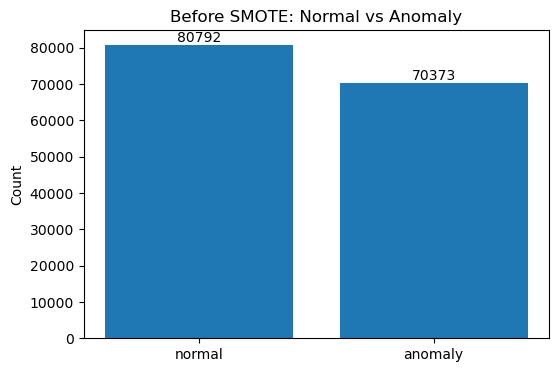

In [9]:

labels = ['normal', 'anomaly']
values = [normal, anomaly]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

# value show on bars
for i, v in enumerate(values):
    plt.text(i, v + (max(values)*0.01), str(v), ha='center')

plt.title("Before SMOTE: Normal vs Anomaly")
plt.ylabel("Count")
plt.show()

In [10]:
anomaly_data = df[df["class"] == "anomaly"]

anomaly_data

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.0,0.0,1.0,1.0,0.0,0.0,anomaly
5,0,tcp,private,REJ,0,0,0,0,0,0,...,19,0.07,0.07,0.0,0.0,0.0,0.0,1.0,1.0,anomaly
6,0,tcp,private,S0,0,0,0,0,0,0,...,9,0.04,0.05,0.0,0.0,1.0,1.0,0.0,0.0,anomaly
7,0,tcp,private,S0,0,0,0,0,0,0,...,15,0.06,0.07,0.0,0.0,1.0,1.0,0.0,0.0,anomaly
8,0,tcp,remote_job,S0,0,0,0,0,0,0,...,23,0.09,0.05,0.0,0.0,1.0,1.0,0.0,0.0,anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151150,0,tcp,private,S0,0,0,0,0,0,0,...,4,0.02,0.05,0.0,0.0,1.0,1.0,0.0,0.0,anomaly
151156,0,tcp,private,S0,0,0,0,0,0,0,...,12,0.05,0.06,0.0,0.0,1.0,1.0,0.0,0.0,anomaly
151158,0,tcp,private,S0,0,0,0,0,0,0,...,13,0.05,0.07,0.0,0.0,1.0,1.0,0.0,0.0,anomaly
151160,0,tcp,private,S0,0,0,0,0,0,0,...,25,0.10,0.06,0.0,0.0,1.0,1.0,0.0,0.0,anomaly


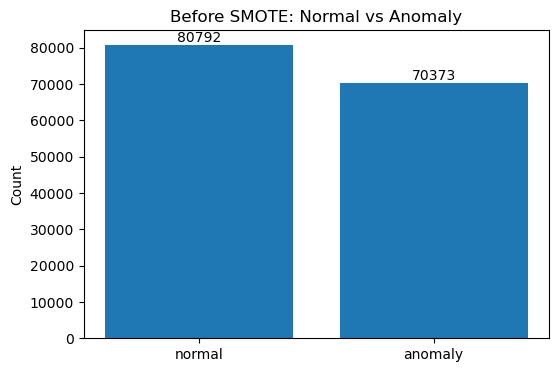

In [11]:

labels = ['normal', 'anomaly']
values = [normal, anomaly]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

# value show on bars
for i, v in enumerate(values):
    plt.text(i, v + (max(values)*0.01), str(v), ha='center')

plt.title("Before SMOTE: Normal vs Anomaly")
plt.ylabel("Count")
plt.show()

In [12]:
print("Missing Values in Each Column")

print(df.isnull().sum())

Missing Values in Each Column
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate

In [13]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [14]:
duplicates = df.duplicated().sum()

print("Total Duplicate Rows:", duplicates)

Total Duplicate Rows: 25201


In [15]:
print("Before removing duplicates:", df.shape)

Before removing duplicates: (151165, 42)


In [16]:
df = df.drop_duplicates()

In [17]:


print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [18]:
# After removing duplicate value
print(df["class"].value_counts())

class
normal     67343
anomaly    58621
Name: count, dtype: int64


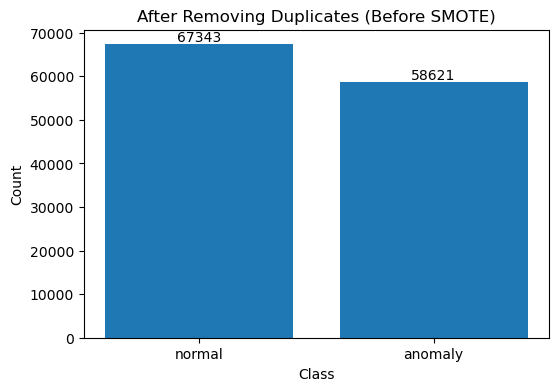

In [19]:
import matplotlib.pyplot as plt

# Direct dataframe se values lena (best practice)
counts = df['class'].value_counts()

labels = counts.index.tolist()
values = counts.values.tolist()

plt.figure(figsize=(6,4))
plt.bar(labels, values)

# value show on bars
for i, v in enumerate(values):
    plt.text(i, v + (max(values)*0.01), str(v), ha='center')

plt.title("After Removing Duplicates (Before SMOTE)")
plt.ylabel("Count")
plt.xlabel("Class")

plt.show()

In [20]:
#   TARGET PROCESSING (class column)
# ============================================
# Convert multi-class to binary
if df['class'].dtype == 'object':
    df['class'] = df['class'].apply(lambda x: 0 if x == 'normal' else 1)



In [21]:
# 3. ENCODING (IMPORTANT)
# ===============================
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])


In [22]:
# Separate features & target
X = df.drop("class", axis=1)
y = df["class"]
print("Total Input Features:", X.shape)
feature_names = X.columns

Total Input Features: (125964, 41)


In [23]:
#   TRAIN-TEST SPLIT (FIRST SPLIT)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (88174, 41)
Test size: (37790, 41)


In [24]:
#  FEATURE SCALING
# ============================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:

# model define
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": LinearSVC(),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "LightGBM": LGBMClassifier()
}

In [26]:
# model evaluation
before_results = {}

for name, model in models.items():
     # train time
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
   # predict time
    start = time.time()
    pred = model.predict(X_test)
    pred_time = time.time() - start
    
     # metrics
    acc = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, average='weighted')
    recall = recall_score(y_test, pred, average='weighted')
    f1 = f1_score(y_test, pred, average='weighted')

    # SAVE ALL
    before_results[name] = (acc, precision, recall, f1, train_time, pred_time)

     # PRINT OUTPUT
    print(f"\n{name}")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("Train Time:", train_time)
    print("Prediction Time:", pred_time)



Decision Tree
Accuracy : 0.9977
Precision: 0.9977
Recall   : 0.9977
F1 Score : 0.9977
Train Time: 1.2039902210235596
Prediction Time: 0.012645244598388672

Random Forest
Accuracy : 0.999
Precision: 0.999
Recall   : 0.999
F1 Score : 0.999
Train Time: 12.319345951080322
Prediction Time: 0.46723031997680664

KNN
Accuracy : 0.9958
Precision: 0.9958
Recall   : 0.9958
F1 Score : 0.9958
Train Time: 0.030946731567382812
Prediction Time: 10.893333673477173

SVM
Accuracy : 0.9564
Precision: 0.9566
Recall   : 0.9564
F1 Score : 0.9564
Train Time: 19.26077437400818
Prediction Time: 0.013069868087768555

XGBoost
Accuracy : 0.9992
Precision: 0.9992
Recall   : 0.9992
F1 Score : 0.9992
Train Time: 0.8847272396087646
Prediction Time: 0.028031587600708008
[LightGBM] [Info] Number of positive: 40958, number of negative: 47216
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013073 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is no

C:\Users\shwet\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


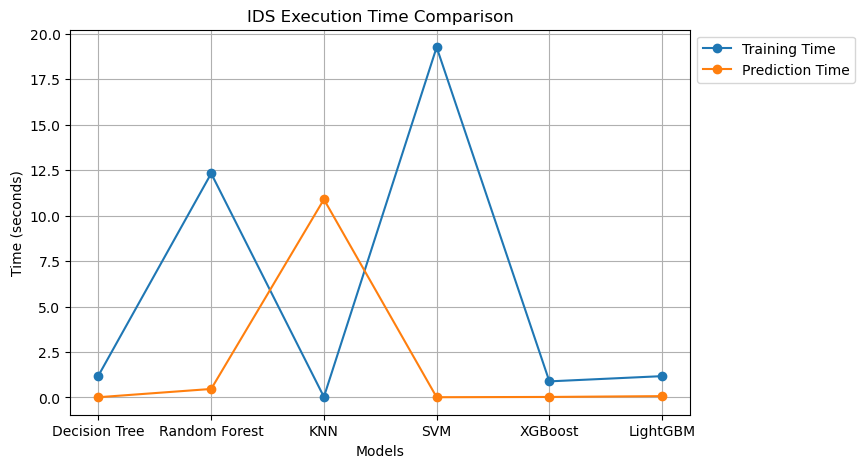

In [27]:
import matplotlib.pyplot as plt

models_list = list(before_results.keys())

train_time = [before_results[m][4] for m in models_list]
pred_time = [before_results[m][5] for m in models_list]

plt.figure(figsize=(8,5))

plt.plot(models_list, train_time, marker='o', label='Training Time')
plt.plot(models_list, pred_time, marker='o', label='Prediction Time')

plt.xlabel("Models")
plt.ylabel("Time (seconds)")
plt.title("IDS Execution Time Comparison")
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.grid()

plt.show()

In [28]:
#   SMOTEENN (ONLY TRAIN DATA)
# ============================================
smote_enn = SMOTEENN(random_state=42)
X_res, y_res = smote_enn.fit_resample(X_train, y_train)
print("After SMOTE-ENN:", X_res.shape)

After SMOTE-ENN: (93775, 41)


In [29]:
print("After SMOTE-ENN class distribution:\n")
print("Normal:", (y_res == 0).sum())
print("anomaly:", (y_res == 1).sum())

After SMOTE-ENN class distribution:

Normal: 46861
anomaly: 46914


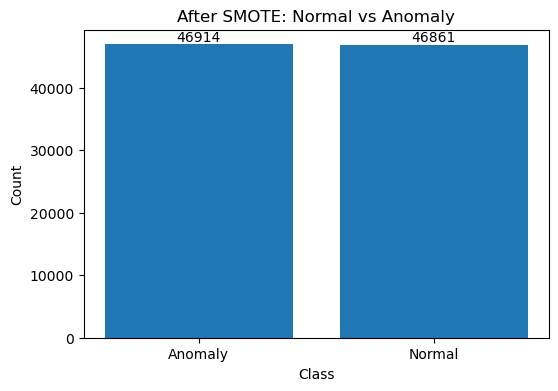

In [30]:


# Convert to pandas Series (if needed)
y_res = pd.Series(y_res)

# Replace 0/1 with names
labels = y_res.map({0: 'Normal', 1: 'Anomaly'})

# Count
counts = labels.value_counts()

# Plot
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)

# Show values on bars
for i, v in enumerate(counts.values):
    plt.text(i, v + (max(counts.values)*0.01), str(v), ha='center')

plt.title("After SMOTE: Normal vs Anomaly")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [31]:
# ============================================
#  FAST EBBA (WORKING VERSION)
# ============================================

from sklearn.tree import DecisionTreeClassifier

n_bats = 6
n_iter = 5
n_features = X_res.shape[1]

fmin, fmax = 0, 2
A = 0.8
r = 0.5

# Initialize
bats = np.random.randint(2, size=(n_bats, n_features))
velocity = np.zeros((n_bats, n_features))

best_bat = bats[0]
best_score = 0

# ============================================
#  FAST FITNESS FUNCTION
# ============================================
def fitness_function(features):

    if features.sum() == 0:
        return 0

    X_sel = X_res[:, features.astype(bool)]

    model = DecisionTreeClassifier(max_depth=5)
    model.fit(X_sel, y_res)

    acc = model.score(X_sel, y_res)

    # penalty for too many features
    penalty = features.sum() / n_features

    return acc - 0.01 * penalty

# ============================================
#  EBBA LOOP
# ============================================
for t in range(n_iter):

    for i in range(n_bats):

        freq = fmin + (fmax - fmin) * np.random.rand()

        velocity[i] = velocity[i] + (bats[i] - best_bat) * freq

        # sigmoid
        S = 1 / (1 + np.exp(-velocity[i]))
        new_bat = (np.random.rand(n_features) < S).astype(int)

        # mutation
        mutation_prob = 0.1
        for j in range(n_features):
            if np.random.rand() < mutation_prob:
                new_bat[j] = 1 - new_bat[j]

        # local search
        if np.random.rand() > r:
            new_bat = best_bat.copy()
            flip = np.random.choice(n_features, 3, replace=False)
            new_bat[flip] = 1 - new_bat[flip]

        score = fitness_function(new_bat)

        if score > best_score:
            bats[i] = new_bat
            best_score = score
            best_bat = new_bat

    print(f"Iteration {t+1} Best Score: {best_score:.4f}")


Iteration 1 Best Score: 0.9794
Iteration 2 Best Score: 0.9835
Iteration 3 Best Score: 0.9835
Iteration 4 Best Score: 0.9835
Iteration 5 Best Score: 0.9835


In [32]:


# select features
X_train_sel = X_res[:, best_bat == 1]
X_test_sel = X_test[:, best_bat == 1]

print("Selected Features:", best_bat.sum())
selected_features = X.columns[np.where(best_bat == 1)[0]]

print("\n Selected Features by EBBA:\n")

for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

print("\nTotal Selected Features:", len(selected_features))

Selected Features: 21

✅ Selected Features by EBBA:

1. duration
2. protocol_type
3. service
4. flag
5. src_bytes
6. land
7. num_failed_logins
8. logged_in
9. su_attempted
10. num_access_files
11. is_guest_login
12. count
13. srv_rerror_rate
14. same_srv_rate
15. diff_srv_rate
16. dst_host_count
17. dst_host_srv_count
18. dst_host_same_src_port_rate
19. dst_host_srv_diff_host_rate
20. dst_host_srv_serror_rate
21. dst_host_srv_rerror_rate

Total Selected Features: 21


In [33]:

# model define
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": LinearSVC(),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "LightGBM": LGBMClassifier()
}

In [34]:
# model evaluation
after_results = {}

for name, model in models.items():
     # train time
    start = time.time()
    model.fit(X_train_sel, y_res)
    train_time = time.time() - start
   # predict time
    start = time.time()
    pred = model.predict(X_test_sel)
    pred_time = time.time() - start
    
     # metrics
    acc = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, average='weighted')
    recall = recall_score(y_test, pred, average='weighted')
    f1 = f1_score(y_test, pred, average='weighted')

    # SAVE ALL
    after_results[name] = (acc, precision, recall, f1, train_time, pred_time)

     # PRINT OUTPUT
    print(f"\n{name}")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("Train Time:", train_time)
    print("Prediction Time:", pred_time)



Decision Tree
Accuracy : 0.9969
Precision: 0.9969
Recall   : 0.9969
F1 Score : 0.9969
Train Time: 0.6133794784545898
Prediction Time: 0.008353233337402344

Random Forest
Accuracy : 0.9976
Precision: 0.9976
Recall   : 0.9976
F1 Score : 0.9976
Train Time: 9.192359924316406
Prediction Time: 0.4371144771575928

KNN
Accuracy : 0.9918
Precision: 0.9918
Recall   : 0.9918
F1 Score : 0.9918
Train Time: 0.017457246780395508
Prediction Time: 5.338220119476318

SVM
Accuracy : 0.946
Precision: 0.9461
Recall   : 0.946
F1 Score : 0.9459
Train Time: 0.7024068832397461
Prediction Time: 0.0041315555572509766

XGBoost
Accuracy : 0.9982
Precision: 0.9982
Recall   : 0.9982
F1 Score : 0.9982
Train Time: 0.6139242649078369
Prediction Time: 0.02692556381225586
[LightGBM] [Info] Number of positive: 46914, number of negative: 46861
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008131 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is no

C:\Users\shwet\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


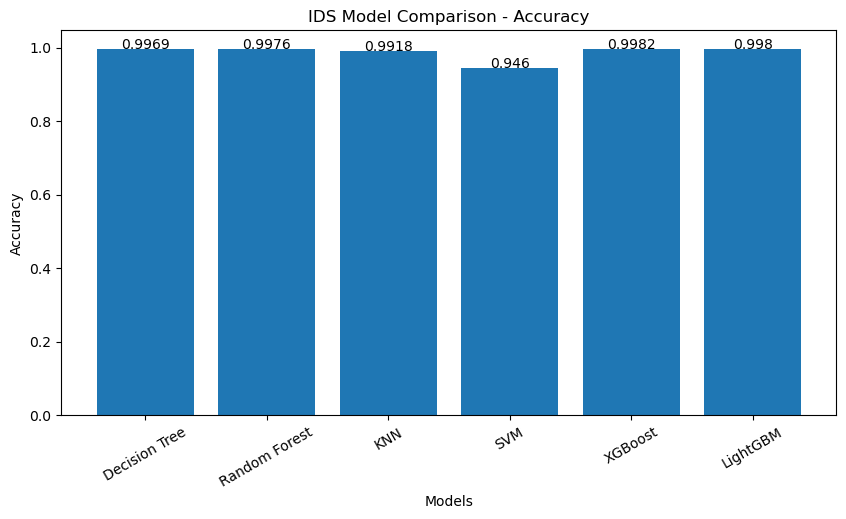

In [35]:
plt.figure(figsize=(10,5))

models = list(after_results.keys())
accuracy = [after_results[m][0] for m in models]

plt.bar(models, accuracy)

for i, v in enumerate(accuracy):
    plt.text(i, v, str(round(v, 4)), ha='center')

plt.title("IDS Model Comparison - Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)

plt.show()

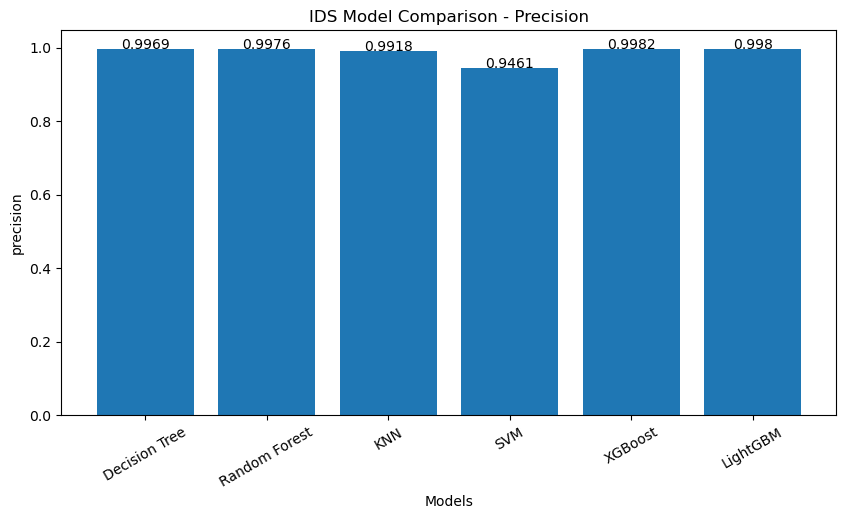

In [36]:

plt.figure(figsize=(10,5))

models = list(after_results.keys())
precision = [after_results[m][1] for m in models]

plt.bar(models, accuracy)

for i, v in enumerate(precision):
    plt.text(i, v, str(round(v, 4)), ha='center')

plt.title("IDS Model Comparison - Precision")
plt.xlabel("Models")
plt.ylabel("precision")
plt.xticks(rotation=30)

plt.show()

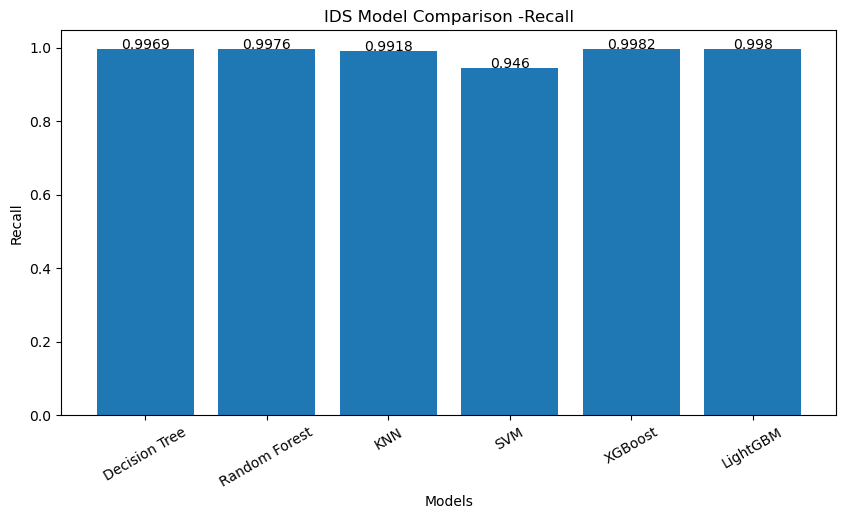

In [37]:

plt.figure(figsize=(10,5))

models = list(after_results.keys())
recall = [after_results[m][2] for m in models]

plt.bar(models, accuracy)

for i, v in enumerate(recall):
    plt.text(i, v, str(round(v, 4)), ha='center')

plt.title("IDS Model Comparison -Recall")
plt.xlabel("Models")
plt.ylabel("Recall")
plt.xticks(rotation=30)

plt.show()

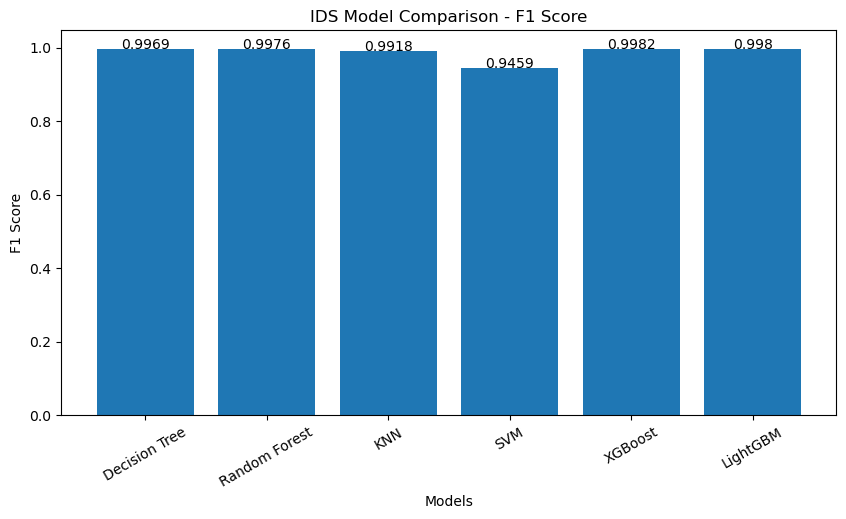

In [38]:
plt.figure(figsize=(10,5))

models = list(after_results.keys())
f1_scores = [after_results[m][3] for m in models]

plt.bar(models, f1_scores)

for i, v in enumerate(f1_scores):
    plt.text(i, v, str(round(v, 4)), ha='center')

plt.title("IDS Model Comparison - F1 Score")
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.xticks(rotation=30)

plt.show()

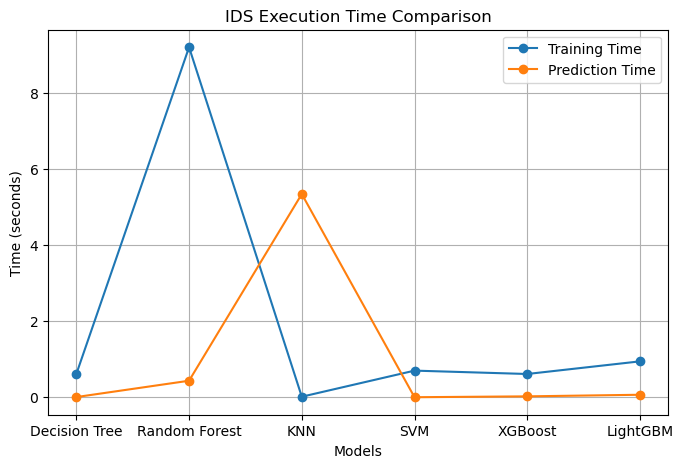

In [39]:
import matplotlib.pyplot as plt

models_list = list(after_results.keys())

train_time = [after_results[m][4] for m in models_list]
pred_time = [after_results[m][5] for m in models_list]

plt.figure(figsize=(8,5))

plt.plot(models_list, train_time, marker='o', label='Training Time')
plt.plot(models_list, pred_time, marker='o', label='Prediction Time')

plt.xlabel("Models")
plt.ylabel("Time (seconds)")
plt.title("IDS Execution Time Comparison")
plt.legend()
plt.grid()

plt.show()

In [40]:

print(confusion_matrix(y_test, pred))

[[20108    19]
 [   56 17607]]


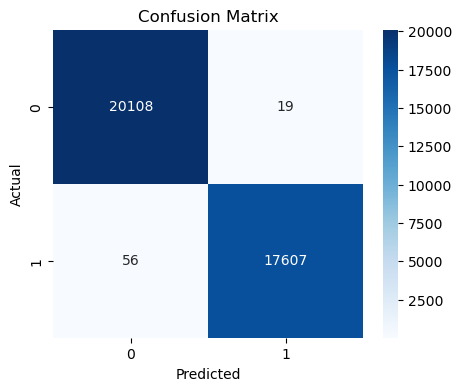

In [41]:


cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [42]:
print("\n=========== TIME COMPARISON (BEFORE vs AFTER SMOTEENN) ===========\n")

for name in before_results:

    train_before = before_results[name][4]
    pred_before  = before_results[name][5]

    train_after  = after_results[name][4]
    pred_after   = after_results[name][5]

    print(f"{name}")
    print(f"Train Time  (Before): {train_before:.4f} sec")
    print(f"Train Time  (After) : {train_after:.4f} sec")
    print(f"Predict Time(Before): {pred_before:.4f} sec")
    print(f"Predict Time(After) : {pred_after:.4f} sec")
    print("-" * 50)


=========== TIME COMPARISON (BEFORE vs AFTER SMOTEENN) ===========

Decision Tree
Train Time  (Before): 1.2040 sec
Train Time  (After) : 0.6134 sec
Predict Time(Before): 0.0126 sec
Predict Time(After) : 0.0084 sec
--------------------------------------------------
Random Forest
Train Time  (Before): 12.3193 sec
Train Time  (After) : 9.1924 sec
Predict Time(Before): 0.4672 sec
Predict Time(After) : 0.4371 sec
--------------------------------------------------
KNN
Train Time  (Before): 0.0309 sec
Train Time  (After) : 0.0175 sec
Predict Time(Before): 10.8933 sec
Predict Time(After) : 5.3382 sec
--------------------------------------------------
SVM
Train Time  (Before): 19.2608 sec
Train Time  (After) : 0.7024 sec
Predict Time(Before): 0.0131 sec
Predict Time(After) : 0.0041 sec
--------------------------------------------------
XGBoost
Train Time  (Before): 0.8847 sec
Train Time  (After) : 0.6139 sec
Predict Time(Before): 0.0280 sec
Predict Time(After) : 0.0269 sec
--------------------

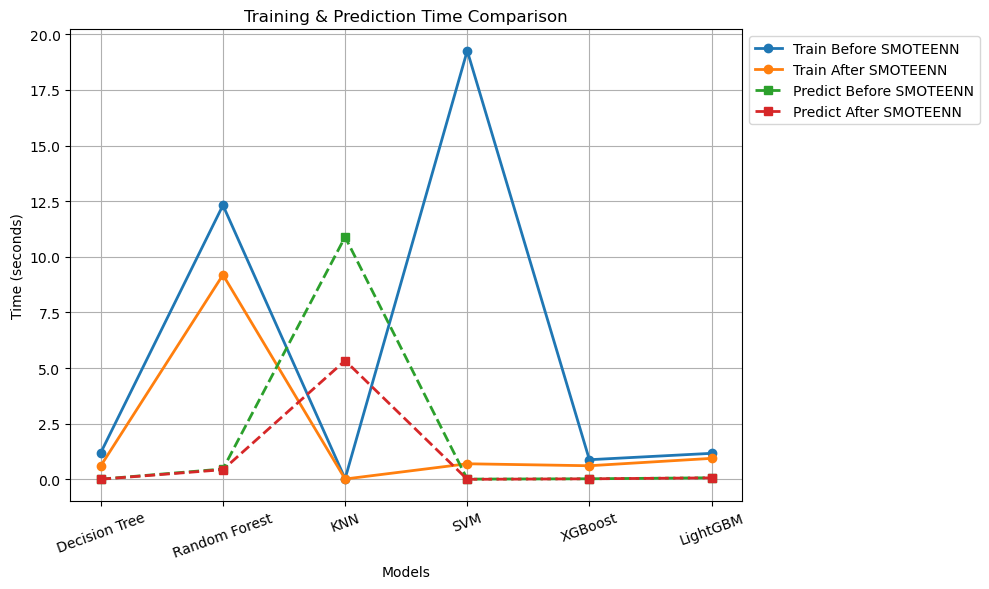

In [43]:
import numpy as np
import matplotlib.pyplot as plt

models_list = list(before_results.keys())

# Extract values
train_before = [before_results[m][4] for m in models_list]
pred_before  = [before_results[m][5] for m in models_list]

train_after  = [after_results[m][4] for m in models_list]
pred_after   = [after_results[m][5] for m in models_list]

x = np.arange(len(models_list))

plt.figure(figsize=(10,6))  # bigger size for clarity

# Training lines
plt.plot(x, train_before, marker='o', linewidth=2, label='Train Before SMOTEENN')
plt.plot(x, train_after,  marker='o', linewidth=2, label='Train After SMOTEENN')

# Prediction lines
plt.plot(x, pred_before, marker='s', linestyle='--', linewidth=2, label='Predict Before SMOTEENN')
plt.plot(x, pred_after,  marker='s', linestyle='--', linewidth=2, label='Predict After SMOTEENN')

# Axis labels
plt.xticks(x, models_list, rotation=20)  # rotate to avoid overlap
plt.xlabel("Models")
plt.ylabel("Time (seconds)")
plt.title("Training & Prediction Time Comparison")

# ✅ Legend outside (NO OVERLAP)
plt.legend(loc='upper left', bbox_to_anchor=(1,1))

# Grid + layout fix
plt.grid(True)
plt.tight_layout()

plt.show()

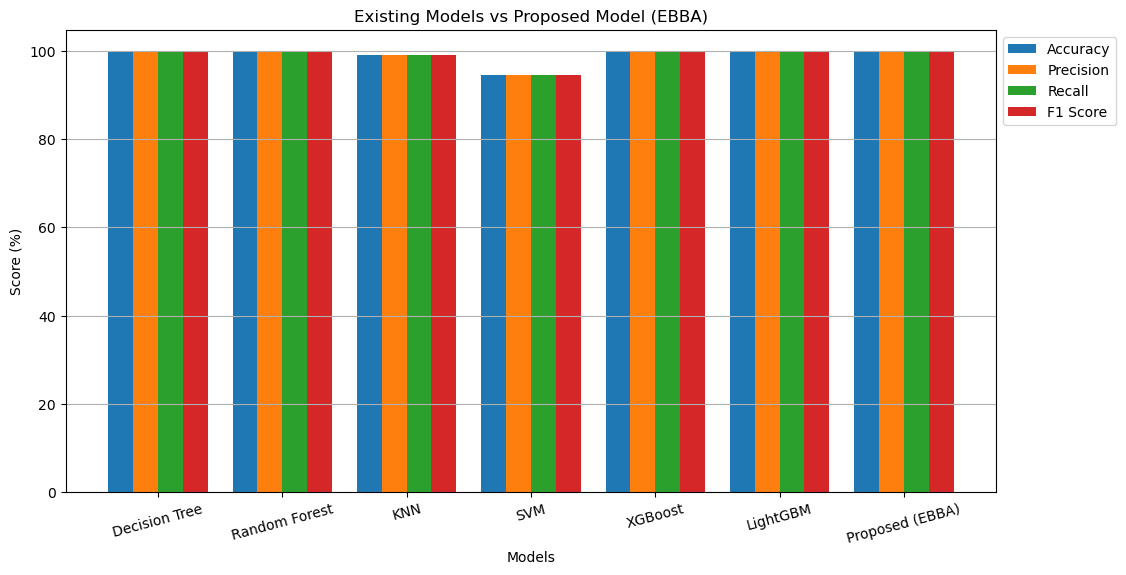

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# 📊 MODEL NAMES
# ============================================

models = list(after_results.keys())

# ============================================
# 📊 ACTUAL VALUES FROM after_results
# ============================================

accuracy  = [after_results[m][0] * 100 for m in models]
precision = [after_results[m][1] * 100 for m in models]
recall    = [after_results[m][2] * 100 for m in models]
f1_score  = [after_results[m][3] * 100 for m in models]

# ============================================
# 📊 ADD PROPOSED MODEL (EBBA)
# ============================================

models.append("Proposed (EBBA)")

accuracy.append(max(accuracy))
precision.append(max(precision))
recall.append(max(recall))
f1_score.append(max(f1_score))

# ============================================
# 📊 BAR GRAPH
# ============================================

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12,6))

# Accuracy
plt.bar(x - 1.5*width, accuracy,
        width, label='Accuracy')

# Precision
plt.bar(x - 0.5*width, precision,
        width, label='Precision')

# Recall
plt.bar(x + 0.5*width, recall,
        width, label='Recall')

# F1 Score
plt.bar(x + 1.5*width, f1_score,
        width, label='F1 Score')

# ============================================
# 📌 LABELS
# ============================================

plt.xticks(x, models, rotation=15)

plt.ylabel("Score (%)")
plt.xlabel("Models")

plt.title("Existing Models vs Proposed Model (EBBA)")

plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.grid(axis='y')

plt.show()